# Week 13 live coding: the carbon cost of a model

A 45-minute tutorial to type through together. The tools this course has taught run on
electricity, and at the scale of modern AI that electricity is a climate question in its own
right. This notebook puts numbers on it using two real datasets and a handful of published
measurements: how much energy training a model takes, how much carbon that becomes on
different grids, how training compares with serving the model afterwards, and who ends up
carrying the cost.

There is no model fitting in this notebook. It is arithmetic on real data, which is most of
what policy analysis is.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Not all kilowatt-hours are equal

The same computation emits very different amounts of CO$_2$ depending on where it runs. Our
World in Data publishes the **carbon intensity of electricity** for every country, in grams
of CO$_2$ per kilowatt-hour, from Ember and the Energy Institute.

(6332, 4)
years: 1990 to 2025


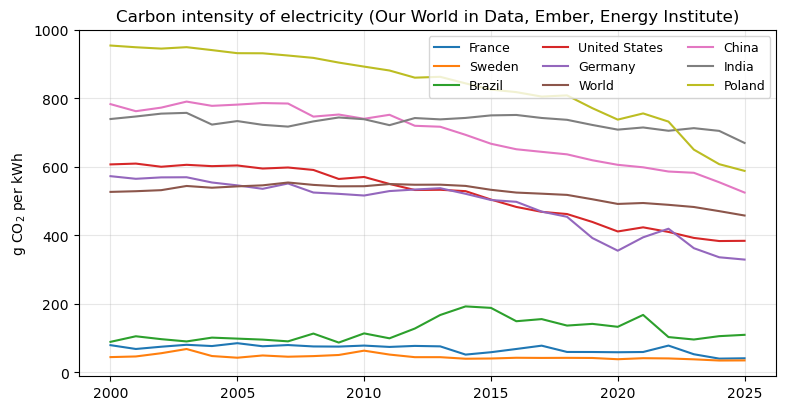

entity
France            53.0
Sweden            38.0
Brazil            96.0
United States    393.0
Germany          363.0
World            483.0
China            583.0
India            713.0
Poland           651.0
Name: g_per_kwh, dtype: float64


In [2]:
url = "https://ourworldindata.org/grapher/carbon-intensity-electricity.csv?v=1&csvType=full&useColumnShortNames=true"
ci = pd.read_csv(url, storage_options={"User-Agent": "Mozilla/5.0"})
ci = ci.rename(columns={"co2_intensity__gco2_kwh": "g_per_kwh"})
print(ci.shape)
print("years:", ci["year"].min(), "to", ci["year"].max())

show = ["France", "Sweden", "Brazil", "United States", "Germany", "World", "China", "India", "Poland"]
fig, ax = plt.subplots(figsize=(9, 4.5))
for name in show:
    s = ci[(ci["entity"] == name) & (ci["year"] >= 2000)]
    ax.plot(s["year"], s["g_per_kwh"], label=name, lw=1.5)
ax.set_ylabel("g CO$_2$ per kWh")
ax.set_title("Carbon intensity of electricity (Our World in Data, Ember, Energy Institute)")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.show()

latest = ci[ci["year"] == 2023].set_index("entity")["g_per_kwh"]
print(latest[show].round(0))

A factor of more than ten separates France and Sweden from India and Poland. Germany has
fallen by more than a third since 2000 while India has barely moved. The world average sits
near 480, between the United States and China. Keep these numbers in mind: every estimate below is one
of them multiplied by an energy figure.

## 2. What training a model costs

These are published, measured or company-reported energy figures for training runs. They are
the best numbers available and they are also incomplete: they generally cover the final run
only, not the failed experiments and hyperparameter searches that preceded it, and they
exclude the energy of manufacturing the hardware.

| Model | Year | Energy (MWh) | Source |
| --- | --- | --- | --- |
| BERT base | 2018 | 1.5 | Strubell, Ganesh and McCallum 2019 |
| T5 (11B) | 2019 | 86 | Patterson et al. 2021 |
| GPT-3 (175B) | 2020 | 1,287 | Patterson et al. 2021 |
| BLOOM (176B) | 2022 | 433 | Luccioni, Viguier and Ligozat 2022 |
| Llama 2 (all sizes) | 2023 | 1,325 | Touvron et al. 2023, 3.31 million GPU-hours at 400 W |
| Llama 3.1 405B | 2024 | 21,600 | Meta 2024 model card, 30.84 million GPU-hours at 700 W |

The two Llama rows are GPU-hours multiplied by the per-GPU power the companies used in their
own accounting, so they are upper-bound estimates of processor energy rather than
measurements of the whole facility.

In [3]:
training = pd.DataFrame({
    "model":  ["BERT base", "T5 11B", "GPT-3 175B", "BLOOM 176B", "Llama 2 family", "Llama 3.1 405B"],
    "year":   [2018, 2019, 2020, 2022, 2023, 2024],
    "mwh":    [1.5, 86, 1287, 433, 3.31e6 * 400 / 1e6, 30.84e6 * 700 / 1e6],
}).set_index("model")

grids = ["France", "Sweden", "United States", "World", "India", "Poland"]
t_co2 = pd.DataFrame({g: training["mwh"] * latest[g] / 1000 for g in grids})   # MWh * g/kWh = kg; /1000 = t
print("tonnes of CO2 if the training run drew from each grid (2023 intensities):")
print(t_co2.round(1))

tonnes of CO2 if the training run drew from each grid (2023 intensities):
                France  Sweden  United States    World    India   Poland
model                                                                   
BERT base          0.1     0.1            0.6      0.7      1.1      1.0
T5 11B             4.6     3.3           33.8     41.6     61.3     56.0
GPT-3 175B        68.5    49.4          505.6    621.9    918.1    837.4
BLOOM 176B        23.1    16.6          170.1    209.2    308.9    281.7
Llama 2 family    70.5    50.9          520.2    639.7    944.5    861.5
Llama 3.1 405B  1149.8   829.4         8481.7  10430.9  15400.0  14046.9


Read across a row: the same GPT-3 training run is about 70 tonnes on the French grid and over
900 on the Indian one. Read down a column: six years of model scaling took the energy of one
training run from a couple of months of one household's electricity to the annual use of about two thousand households. Both
directions matter for policy. Siting is a lever that changes emissions by an order of magnitude
without changing the model, and scale is growing faster than grids are cleaning up.

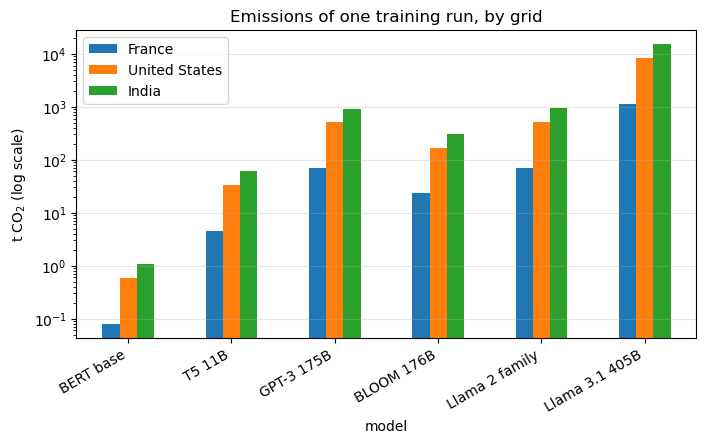

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
t_co2[["France", "United States", "India"]].plot.bar(ax=ax, logy=True)
ax.set_ylabel("t CO$_2$ (log scale)")
ax.set_title("Emissions of one training run, by grid")
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=30, ha="right")
plt.show()

**Put it in human terms.** Our World in Data's CO$_2$ dataset gives per-capita emissions by
country. A training run can be expressed as a number of person-years of emissions, and the
answer depends on whose year you use.

In [5]:
co2 = pd.read_csv("https://github.com/owid/co2-data/raw/master/owid-co2-data.csv",
                  usecols=["country", "year", "co2_per_capita"])
pc = co2[co2["year"] == 2022].set_index("country")["co2_per_capita"]
people = ["United States", "China", "India", "Ethiopia", "World"]
print("per-person CO2 in 2022 (t/yr):"); print(pc[people].round(2)); print()

run = t_co2.loc["GPT-3 175B", "United States"]
print(f"GPT-3 trained on the US grid: {run:.0f} t CO2, equal to")
for p in people:
    print(f"  {run / pc[p]:8.0f} person-years of emissions at the {p} rate")

per-person CO2 in 2022 (t/yr):
country
United States    14.80
China             8.22
India             1.99
Ethiopia          0.14
World             4.68
Name: co2_per_capita, dtype: float64

GPT-3 trained on the US grid: 506 t CO2, equal to
        34 person-years of emissions at the United States rate
        62 person-years of emissions at the China rate
       255 person-years of emissions at the India rate
      3746 person-years of emissions at the Ethiopia rate
       108 person-years of emissions at the World rate


## 3. Training is the small part

A model is trained once and then queried billions of times. Luccioni, Jernite and Strubell
(2023) measured the energy of running common model types on the same hardware, per thousand
requests. The spread across tasks is a factor of a thousand.

In [6]:
# kWh per 1,000 inferences, mean over the models tested (Luccioni, Jernite and Strubell 2023, Table 2)
inference = pd.Series({
    "text classification": 0.002,
    "image classification": 0.007,
    "summarization": 0.049,
    "text generation": 0.047,
    "image generation": 2.907,
}, name="kwh_per_1000")

queries_per_day = 1e9      # the order of magnitude of a widely used consumer service
annual_mwh = inference * queries_per_day / 1000 * 365 / 1000
annual_t = annual_mwh * latest["World"] / 1000

table = pd.DataFrame({"kWh per 1000 requests": inference,
                      "MWh per year at 1e9/day": annual_mwh.round(0),
                      "t CO2 per year (world grid)": annual_t.round(0)})
print(table)
print()
print(f"for comparison, training GPT-3 once: {training.loc['GPT-3 175B', 'mwh']:.0f} MWh")

                      kWh per 1000 requests  MWh per year at 1e9/day  \
text classification                   0.002                    730.0   
image classification                  0.007                   2555.0   
summarization                         0.049                  17885.0   
text generation                       0.047                  17155.0   
image generation                      2.907                1061055.0   

                      t CO2 per year (world grid)  
text classification                         353.0  
image classification                       1235.0  
summarization                              8642.0  
text generation                            8289.0  
image generation                         512681.0  

for comparison, training GPT-3 once: 1287 MWh


At a billion text requests a day, a year of inference uses more than ten times the energy of
the training run. At a billion image generations a day it is nearly a thousand times more. Whether
those request volumes are realistic is exactly the kind of question the companies do not
publish answers to, which is why the paper had to measure models itself. The policy point is
that reporting requirements focused on training miss where most of the energy goes.

## 4. Where the clean electricity is

Data centres go where power is cheap, land is available, and latency to users is low. Clean
grids are a separate list. Join the carbon intensity table with income per person and look.

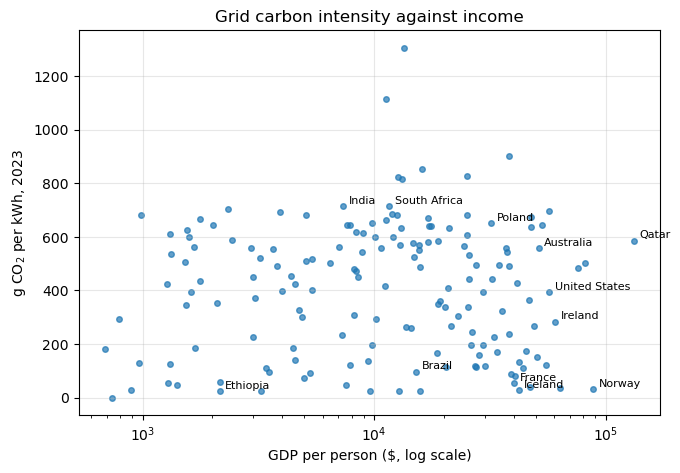

162 countries; correlation of log income with intensity: 0.03


In [7]:
gdp = pd.read_csv("https://github.com/owid/co2-data/raw/master/owid-co2-data.csv",
                  usecols=["country", "iso_code", "year", "gdp", "population"])
gdp["iso_code"] = gdp["iso_code"].fillna("")
gdp = gdp[(gdp["year"] == 2022) & (gdp["iso_code"] != "") & ~gdp["iso_code"].str.startswith("OWID")]
gdp["gdp_pc"] = gdp["gdp"] / gdp["population"]
joined = gdp.set_index("country")[["gdp_pc"]].join(latest.rename("g_per_kwh"), how="inner").dropna()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(joined["gdp_pc"], joined["g_per_kwh"], s=16, alpha=0.7)
for name in ["Norway", "France", "United States", "Ireland", "Poland", "India", "South Africa",
             "Iceland", "Ethiopia", "Australia", "Brazil", "Qatar"]:
    if name in joined.index:
        ax.annotate(name, (joined.loc[name, "gdp_pc"], joined.loc[name, "g_per_kwh"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("GDP per person ($, log scale)")
ax.set_ylabel("g CO$_2$ per kWh, 2023")
ax.set_title("Grid carbon intensity against income")
ax.grid(alpha=0.3)
plt.show()
print(f"{len(joined)} countries; correlation of log income with intensity: {np.corrcoef(np.log10(joined['gdp_pc']), joined['g_per_kwh'])[0, 1]:.2f}")

There is almost no relationship. Rich countries can be clean (Norway, France, Iceland, from
hydro and nuclear) or dirty (Australia, Poland, from coal), and so can poor ones. Grid carbon
is set by geology and past political choices, not by wealth. Two consequences for the
geography of AI:

- The countries best placed to host low-carbon compute are a short and specific list, and
  most of the world's AI infrastructure is not on it. Northern Virginia, the largest data
  centre market on Earth, sits on a grid near the US average.
- The countries most exposed to climate impacts are largely not the countries where compute
  lives or where its benefits accrue. The emissions land on a shared atmosphere. The models
  do not.

## 5. What the numbers leave out

Every figure above is an underestimate of some kind, and knowing how is part of reading them.

- **Embodied emissions and idle power.** Making a GPU, and the building around it, emits
  carbon before a single model runs, and a cluster draws power while it waits. Luccioni et
  al. put manufacturing at about a fifth of BLOOM's total footprint and idle power at
  another quarter, so the training run itself was only about half.
- **Water.** Cooling a data centre evaporates water, and the largest sites are in places
  where water is already contested.
- **Accounting method.** Meta reports its Llama 3 training as zero net emissions because its
  electricity purchases are matched by renewable energy contracts. That is legitimate under market-based accounting and says
  nothing about the physical grid the data centre drew from, which is what the location-based
  numbers above use. When a company reports a footprint, ask which method.
- **Self-reporting.** Nearly all training energy numbers come from the companies that trained
  the models. Independent measurement exists for a handful of open models, which is why BLOOM
  appears in every comparison.

## For the discussion

Three questions to bring to the second half of class.

1. The French grid makes a training run twenty times cleaner than the Polish one. Should
   climate researchers, whose work is explicitly about emissions, choose where their compute
   runs? What would that cost them in practice?
2. If inference dominates, the relevant policy target is the number of requests, which is the
   product being sold. What regulation of that is plausible, and what would it cost the
   public benefits that these tools also provide?
3. Which of the numbers in this notebook would you trust enough to put in a paper, and what
   would you need before trusting the rest?